In [399]:
ML_DATA_TRAIN_PATH = './../data/model_3_data/ml_data_train.csv'
ML_DATA_VAL_PATH = './../data/model_3_data/ml_data_val.csv'
ML_DATA_TEST_PATH = './../data/model_3_data/ml_data_test.csv'
import sqlite3
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.python.client import device_lib
import os
import sys
from collections import Counter
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input, BatchNormalization, Activation, Add, LeakyReLU, Concatenate, Multiply
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras import layers
from tensorflow.keras.applications import InceptionResNetV2, VGG16, MobileNetV2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import Loss
from keras import backend as K
from PIL import Image
import requests
import zipfile

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output as cls
from keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
import pandas as pd
import PIL

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import statistics
import ast
import json
import statistics

import glob
import cv2
from PIL import Image
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

import chess

module_path = os.path.abspath(os.path.join('..', 'utils'))
if module_path not in sys.path:
    sys.path.append(module_path)

from utils2 import plot_graph, bar_plot, two_bar_plot, StepwiseLogger, decode_pos

In [734]:
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, file_path, read_size, batch_size, num_classes, csv_length, initial_pos = True, final_pos = False, legal_moves = False, move = False, single_move = False):
        self.file_path = file_path
        self.batch_size = batch_size
        self.read_size = read_size
        self.num_classes = num_classes
        self.csv_length = csv_length
        self.current_read = None
        self.initial_pos = initial_pos
        self.final_pos = final_pos
        self.legal_moves = legal_moves
        self.move = move
        self.single_move = single_move
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(self.csv_length / self.batch_size))

    def on_epoch_end(self):
        pass

    def __getitem__(self, index):
        if index % (self.read_size // self.batch_size) == 0:
            self.current_read = pd.read_csv(self.file_path, skiprows=range(1, (index * self.batch_size) + 1), nrows=self.read_size)
        batch = self.get_batch(index % (self.read_size // self.batch_size))
        X, y = self.__data_generation__(batch)
        return X, y

    def __data_generation__(self, df):
        X = np.array(df['board'].apply(json.loads).tolist())
        if self.initial_pos and not self.final_pos:
            y = self.encode_pos(df['initial_pos'])
        elif self.final_pos and not self.initial_pos:
            y = self.encode_pos(df['final_pos'])
        elif self.initial_pos and self.final_pos:
            y = [self.encode_pos(df['initial_pos']), self.encode_pos(df['final_pos'])]
        if self.move:
            y = self.encode_move_one_hot(df['move'])
        if self.single_move:
            y = self.encode_single_move(df['move'])
        return X, y
    
    def get_batch(self, index):
        start = index * self.batch_size
        end = start + self.batch_size
        return self.current_read.iloc[start:end]

    def encode_pos(self, positions):
        column_to_number = {
            'a': 1,
            'b': 2,
            'c': 3,
            'd': 4,
            'e': 5,
            'f': 6,
            'g': 7,
            'h': 8
        }
        encoded_positions = []
        for pos in positions:
            encoded_positions.append((column_to_number.get(pos[0]) - 1) +  ((8 - int(pos[1])) * 8))
        return np.array(encoded_positions)
    
    def encode_move_one_hot(self, moves):
        column_to_number = {
            'a': 1,
            'b': 2,
            'c': 3,
            'd': 4,
            'e': 5,
            'f': 6,
            'g': 7,
            'h': 8
        }
        encoded_moves = []
        for move in moves:
            encoded_initial_pos = np.zeros(64)
            encoded_initial_pos[((column_to_number.get(move[0]) - 1)) +  ((8 - int(move[1])) * 8)] = 1
            encoded_final_pos = np.zeros(64)
            encoded_final_pos[((column_to_number.get(move[2]) - 1)) +  ((8 - int(move[3])) * 8)] = 1

            encoded_moves.append(np.concatenate((encoded_initial_pos, encoded_final_pos), axis=None))
        return np.array(encoded_moves)
    
    def encode_single_move(self, moves):
        column_to_number = {
            'a': 1,
            'b': 2,
            'c': 3,
            'd': 4,
            'e': 5,
            'f': 6,
            'g': 7,
            'h': 8
        }
        encoded_moves = []
        for move in moves:
            enconded_move = np.zeros(4096)
            enconded_move[(((column_to_number.get(move[0]) - 1)) +  ((8 - int(move[1])) * 8)) * 64 + (((column_to_number.get(move[2]) - 1)) +  ((8 - int(move[3])) * 8))] = 1
            encoded_moves.append(enconded_move)
        return np.array(encoded_moves)



In [3]:
read_size = 2048
batch_size = 32
num_classes = 64
train_data_generator = DataGenerator(ML_DATA_TRAIN_PATH, read_size, batch_size, num_classes, 27913, initial_pos = True, final_pos=True, legal_moves= True)
val_data_generator = DataGenerator(ML_DATA_VAL_PATH, read_size, batch_size, num_classes, 3102, initial_pos = True, final_pos=True)
test_data_generator = DataGenerator(ML_DATA_TEST_PATH, read_size, batch_size, num_classes, 3447, initial_pos = True, final_pos=True)

In [4]:
def create_model(board_shape):
    board_input = Input(shape=board_shape)

    cnn1 = Conv2D(8, (3, 3), padding='same', activation='sigmoid')(board_input)
    cnn1 = BatchNormalization()(cnn1)
    cnn1 = Dropout(0.2)(cnn1)
    
    cnn2 = Conv2D(32, (3, 3), padding='same', activation='sigmoid')(cnn1)
    cnn2 = BatchNormalization()(cnn2)
    cnn2 = Dropout(0.2)(cnn2)
    
    cnn3 = Conv2D(64, (3, 3), padding='same', activation='sigmoid')(cnn2)
    cnn3 = BatchNormalization()(cnn3)
    cnn3 = Dropout(0.2)(cnn3)

    latent_space = Flatten()(cnn3)
    
    mlp_initial_pos = Dense(256, activation='sigmoid')(latent_space)
    mlp_initial_pos = Dropout(0.2)(mlp_initial_pos)
    mlp_initial_pos = Dense(128, activation='sigmoid')(mlp_initial_pos)
    mlp_initial_pos = Dropout(0.2)(mlp_initial_pos)

    initial_pos_preds = Dense(64, activation='softmax', name = 'initial_pos')(mlp_initial_pos)
    
    combined_features = Concatenate()([latent_space, initial_pos_preds])

    mlp_final_pos = Dense(256, activation='sigmoid')(combined_features)
    mlp_final_pos = Dropout(0.2)(mlp_final_pos)
    mlp_final_pos = Dense(128, activation='sigmoid')(mlp_final_pos)
    mlp_final_pos = Dropout(0.2)(mlp_final_pos)

    final_pos_preds = Dense(64, activation='softmax', name = 'final_pos')(mlp_final_pos)


    model = Model(inputs=board_input, outputs=[initial_pos_preds, final_pos_preds])
    return model

In [5]:
INPUT_SHAPE = (8, 8, 6)
LEGAL_MOVES_SHAPE = (1,)
model = create_model(INPUT_SHAPE)

In [6]:
class CustomLoss(Loss):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, y_true, y_pred):
        loss = tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred))
        return loss

In [7]:
model.compile(optimizer='Adam', loss=CustomLoss(), metrics='accuracy')
steps_per_epoch_val = len(val_data_generator)
stepwise_logger = StepwiseLogger(val_data_generator, steps_per_epoch_val, 500)

In [ ]:
history = model.fit(train_data_generator, epochs=1, validation_data=val_data_generator, shuffle=False, callbacks=[stepwise_logger, EarlyStopping(patience=5, restore_best_weights=True)])

In [8]:
def calculate_legal_moves(pgns):
    for pgn in pgns:
        board = chess.Board(pgn)
        legal_moves = [move.uci()[:4] for move in board.legal_moves]
    
    return legal_moves

In [10]:
for epoch in range(1):
    for batch_x, batch_y, pgn in train_data_generator:
        with tf.GradientTape() as tape:
            legal_moves = calculate_legal_moves(pgn)
            y_pred = model(batch_x, training=True)
            loss = model.loss(batch_y, y_pred)
        
        grads = tape.gradient(loss, model.trainable_variables)
        model.optimizer.apply_gradients(zip(grads, model.trainable_variables))

In [110]:
model.evaluate(test_data_generator)

108/108 [==============================] - 1s 5ms/step - loss: 6.3386 - initial_pos_loss: 2.9099 - final_pos_loss: 3.4287 - initial_pos_accuracy: 0.2509 - final_pos_accuracy: 0.1629


[6.338628768920898,
 2.9099133014678955,
 3.428715705871582,
 0.2508680522441864,
 0.16290509700775146]

# Movement Prediction Model
Only concatenating both initial and final positions to generate the move in one hot encoding.

In [828]:
read_size = 2048
batch_size = 32
num_classes = 64
train_data_generator = DataGenerator(ML_DATA_TRAIN_PATH, read_size, batch_size, num_classes, 27913, move=True)
val_data_generator = DataGenerator(ML_DATA_VAL_PATH, read_size, batch_size, num_classes, 3102, move=True)
test_data_generator = DataGenerator(ML_DATA_TEST_PATH, read_size, batch_size, num_classes, 3447, move=True)

In [829]:
def create_model(board_shape):
    board_input = Input(shape=board_shape)

    cnn1 = Conv2D(8, (3, 3), padding='same', activation='sigmoid')(board_input)
    cnn1 = BatchNormalization()(cnn1)
    cnn1 = Dropout(0.2)(cnn1)
    
    cnn2 = Conv2D(32, (3, 3), padding='same', activation='sigmoid')(cnn1)
    cnn2 = BatchNormalization()(cnn2)
    cnn2 = Dropout(0.2)(cnn2)
    
    cnn3 = Conv2D(64, (3, 3), padding='same', activation='sigmoid')(cnn2)
    cnn3 = BatchNormalization()(cnn3)
    cnn3 = Dropout(0.2)(cnn3)

    latent_space = Flatten()(cnn3)
    
    mlp_initial_pos = Dense(256, activation='sigmoid')(latent_space)
    mlp_initial_pos = Dropout(0.2)(mlp_initial_pos)
    mlp_initial_pos = Dense(128, activation='sigmoid')(mlp_initial_pos)
    mlp_initial_pos = Dropout(0.2)(mlp_initial_pos)

    initial_pos_preds = Dense(64, activation='softmax', name = 'initial_pos')(mlp_initial_pos)
    
    combined_features = Concatenate()([latent_space, initial_pos_preds])

    mlp_final_pos = Dense(256, activation='sigmoid')(combined_features)
    mlp_final_pos = Dropout(0.2)(mlp_final_pos)
    mlp_final_pos = Dense(128, activation='sigmoid')(mlp_final_pos)
    mlp_final_pos = Dropout(0.2)(mlp_final_pos)

    final_pos_preds = Dense(64, activation='softmax', name = 'final_pos')(mlp_final_pos)

    move_preds = Concatenate()([initial_pos_preds, final_pos_preds])

    model = Model(inputs=board_input, outputs=move_preds)
    return model

In [830]:
INPUT_SHAPE = (8, 8, 6)
model = create_model(INPUT_SHAPE)
model.summary()

Model: "model_33"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_34 (InputLayer)          [(None, 8, 8, 6)]    0           []                               
                                                                                                  
 conv2d_99 (Conv2D)             (None, 8, 8, 8)      440         ['input_34[0][0]']               
                                                                                                  
 batch_normalization_99 (BatchN  (None, 8, 8, 8)     32          ['conv2d_99[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 dropout_247 (Dropout)          (None, 8, 8, 8)      0           ['batch_normalization_99[0

In [831]:
def accuracy(y_true, y_pred):
    y_pred = tf.convert_to_tensor(y_pred)
    y_pred_first_half = y_pred[:, :64]
    y_pred_second_half = y_pred[:, 64:128]
    y_pred_binary_first_half = tf.one_hot(tf.argmax(y_pred_first_half, axis=-1), depth=tf.shape(y_pred_first_half)[-1])
    y_pred_binary_second_half = tf.one_hot(tf.argmax(y_pred_second_half, axis=-1), depth=tf.shape(y_pred_second_half)[-1])
    y_pred_concatenated = tf.concat([y_pred_binary_first_half, y_pred_binary_second_half], axis=-1)
    
    all_correct = K.all(K.equal(y_true, y_pred_concatenated), axis=-1)
    
    accuracy = K.mean(K.cast(all_correct, K.floatx()))

    # K.print_tensor(accuracy)
    # K.print_tensor(y_true, summarize=64)
    # K.print_tensor(y_pred_concatenated, summarize=64)

    return accuracy

In [832]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=accuracy)
steps_per_epoch_val = len(val_data_generator)
stepwise_logger = StepwiseLogger(val_data_generator, steps_per_epoch_val, 200)

In [833]:
history = model.fit(train_data_generator, epochs=20, validation_data=val_data_generator, shuffle=False, callbacks=[stepwise_logger, EarlyStopping(patience=5, restore_best_weights=True)])

Epoch 1/20
873/873 [==============================] - 11s 11ms/step - loss: 7.6818 - accuracy: 0.0798 - val_loss: 7.5271 - val_accuracy: 0.0851
Epoch 2/20
873/873 [==============================] - 8s 9ms/step - loss: 7.3076 - accuracy: 0.0975 - val_loss: 7.1879 - val_accuracy: 0.0921
Epoch 3/20
873/873 [==============================] - 8s 10ms/step - loss: 7.0359 - accuracy: 0.0953 - val_loss: 6.9290 - val_accuracy: 0.1079
Epoch 4/20
873/873 [==============================] - 9s 10ms/step - loss: 6.8772 - accuracy: 0.1171 - val_loss: 6.7102 - val_accuracy: 0.1144
Epoch 5/20
873/873 [==============================] - 9s 10ms/step - loss: 6.6918 - accuracy: 0.1201 - val_loss: 6.5560 - val_accuracy: 0.1295
Epoch 6/20
873/873 [==============================] - 10s 11ms/step - loss: 6.5351 - accuracy: 0.1367 - val_loss: 6.4613 - val_accuracy: 0.1363
Epoch 7/20
873/873 [==============================] - 10s 11ms/step - loss: 6.4170 - accuracy: 0.1419 - val_loss: 6.3584 - val_accuracy: 0.15

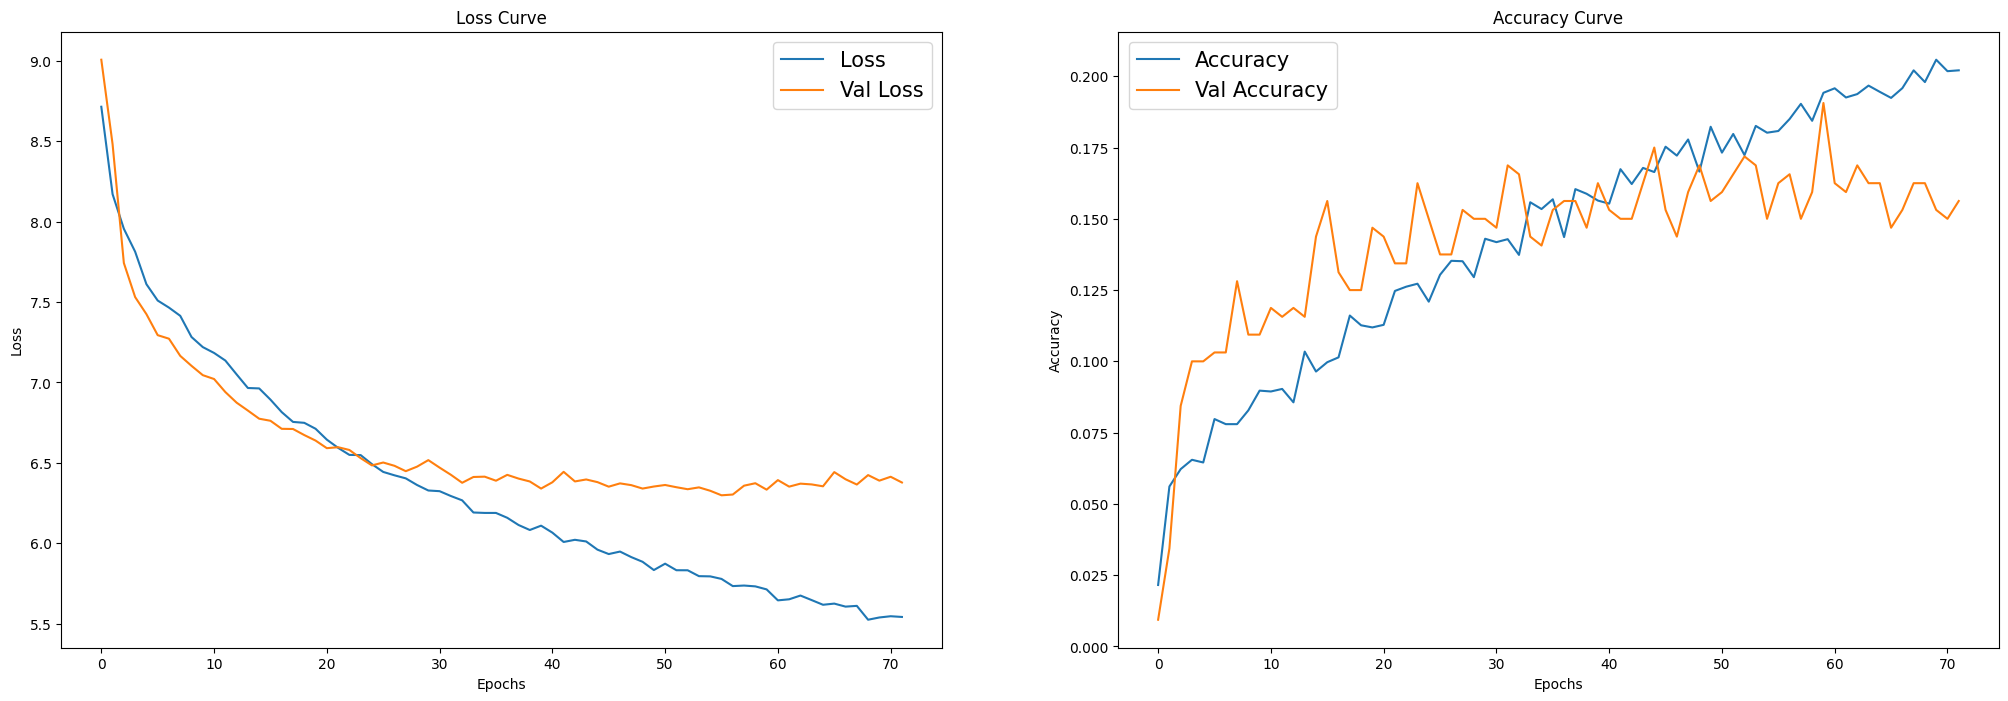

In [834]:
plot_graph(history=stepwise_logger)

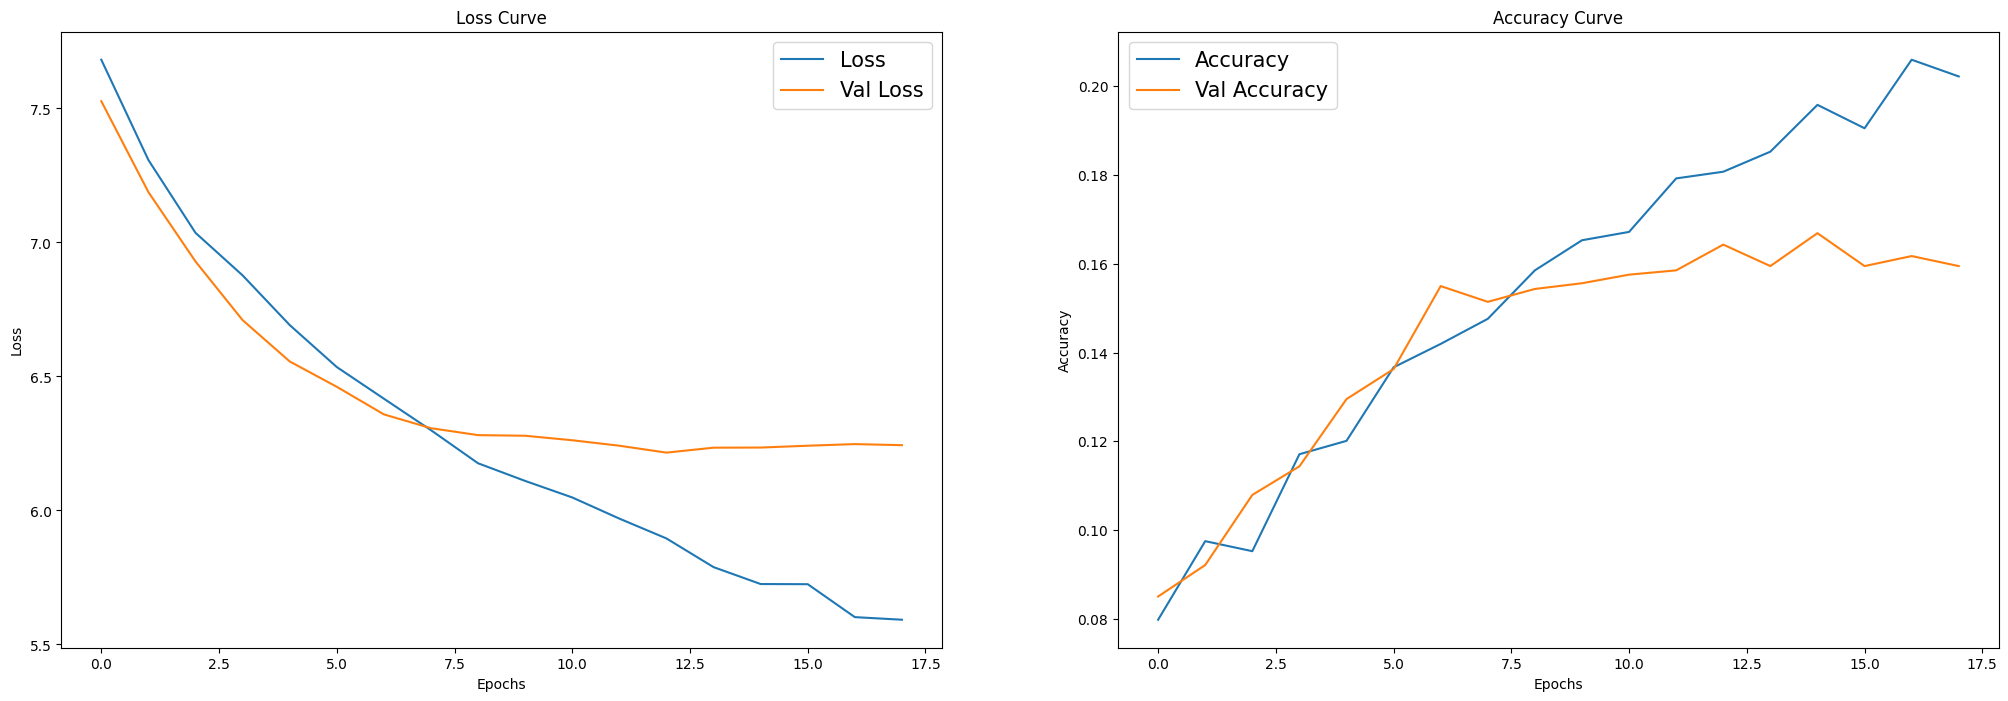

In [835]:
plot_graph(history=history)

In [836]:
model.evaluate(test_data_generator)

108/108 [==============================] - 1s 6ms/step - loss: 6.2981 - accuracy: 0.1641


[6.2980570793151855, 0.1640625]

In [412]:
move_predictions = model.predict(test_data_generator)

108/108 [==============================] - 1s 5ms/step


In [695]:
initial_pos_preds = [move[:64] for move in move_predictions]
final_pos_preds = [move[64:128] for move in move_predictions]

In [ ]:
initial_pos_preds = np.argmax(initial_pos_preds,axis=1)
final_pos_preds = np.argmax(final_pos_preds,axis=1)
initial_pos_preds = decode_pos(initial_pos_preds)
final_pos_preds = decode_pos(final_pos_preds)

In [686]:
def encode_pos(pos):
    column_to_number = {
    'a': 1,
    'b': 2,
    'c': 3,
    'd': 4,
    'e': 5,
    'f': 6,
    'g': 7,
    'h': 8
    }
    encoded_initial_pos = np.zeros(64)
    encoded_initial_pos[((column_to_number.get(pos[0]) - 1)) +  ((8 - int(pos[1])) * 8)] = 1
    
    return [encoded_initial_pos]

In [687]:
def decode_move(positions):
        number_to_column = {
            1 : 'a',
            2 : 'b',
            3 : 'c',
            4 : 'd',
            5 : 'e',
            6 : 'f',
            7 : 'g',
            8 : 'h'
        }
        i = 0
        decoded_movement = ""
        for p in positions:
            if p == 1:
                decoded_pos = number_to_column.get(i %64 % 8 + 1) + str(8 - (i % 64 // 8))
                decoded_movement = decoded_movement + decoded_pos
            i += 1
        return decoded_movement

In [688]:
test_df = pd.read_csv(ML_DATA_TEST_PATH)
def get_move_acc(initial_pos_preds, final_pos_preds, df):
    correct_moves = 0
    correct_blunders = 0
    correct_checks = 0
    i = 0
    for batch in test_data_generator:
        for entry in batch[1]:
            if initial_pos_preds[i] + final_pos_preds[i] == decode_move(entry):
                correct_moves += 1
                if df['is_blunder_cp'][i] == 1:
                    correct_blunders += 1
                if df['is_check'][i] == 1:
                    correct_checks += 1
            i += 1
            
    return correct_moves, correct_blunders, correct_checks

In [689]:
correct_moves, correct_blunders, correct_checks = get_move_acc(initial_pos_preds, final_pos_preds, test_df)

In [690]:
print(str(round(correct_moves/3447*100, 3)) + '%')
print(str(round(correct_blunders/test_df['is_blunder_cp'].sum()*100, 3)) + '%')
print(str(round(correct_checks/test_df['is_check'].sum()*100, 3)) + '%')

15.579%
1.635%
3.789%


In [691]:
len(initial_pos_preds)

3456

In [692]:
def calculate_valid_moves(initial_pos_preds, final_pos_preds, df):
    valid_init_pos = 0
    valid_final_pos = 0
    valid_moves = 0
    for index, row in df.iterrows():
        if index < 3456:
            if(index % 10000 == 0):
                display(index, clear=True)
            board = chess.Board(row['board_pgn'])
            init_pos_predicted = initial_pos_preds[index]
            final_pos_predicted = final_pos_preds[index]
            init_pos_is_legal = init_pos_predicted in [move.uci()[:2] for move in board.legal_moves]
            final_pos_is_legal = final_pos_predicted in [move.uci()[2:4] for move in board.legal_moves]
            move_is_legal = init_pos_predicted + final_pos_predicted in [move.uci()[:4] for move in board.legal_moves]

            if init_pos_is_legal:
                valid_init_pos += 1
            if final_pos_is_legal:
                valid_final_pos += 1
            if move_is_legal:
                valid_moves += 1
    
    return valid_init_pos, valid_final_pos, valid_moves

In [693]:
valid_init_pos, valid_final_pos, valid_moves, = calculate_valid_moves(initial_pos_preds, final_pos_preds, test_df)

0

In [694]:
print(f"Legal Initial Positions: {valid_init_pos}, {round(valid_init_pos/len(initial_pos_preds)*100,3)}%\nLegal Final Positions: {valid_final_pos}, {round(valid_final_pos/len(initial_pos_preds)*100, 3)}%\nLegal Moves: {valid_moves}, {round(valid_moves/len(initial_pos_preds)*100, 3)}%")

Legal Initial Positions: 3345, 96.788%
Legal Final Positions: 3012, 87.153%
Legal Moves: 1844, 53.356%


# Movement Prediction Model 2
Making the prediction of initial and final separetly and returning a sigmoid of 128

In [863]:
read_size = 2048
batch_size = 32
num_classes = 64
train_data_generator = DataGenerator(ML_DATA_TRAIN_PATH, read_size, batch_size, num_classes, 27913, move=True)
val_data_generator = DataGenerator(ML_DATA_VAL_PATH, read_size, batch_size, num_classes, 3102, move=True)
test_data_generator = DataGenerator(ML_DATA_TEST_PATH, read_size, batch_size, num_classes, 3447, move=True)

In [864]:
def create_model_2(board_shape):
    board_input = Input(shape=board_shape)

    cnn1 = Conv2D(8, (3, 3), padding='same', activation='sigmoid')(board_input)
    cnn1 = BatchNormalization()(cnn1)
    cnn1 = Dropout(0.2)(cnn1)
    
    cnn2 = Conv2D(32, (3, 3), padding='same', activation='sigmoid')(cnn1)
    cnn2 = BatchNormalization()(cnn2)
    cnn2 = Dropout(0.2)(cnn2)
    
    cnn3 = Conv2D(64, (3, 3), padding='same', activation='sigmoid')(cnn2)
    cnn3 = BatchNormalization()(cnn3)
    cnn3 = Dropout(0.2)(cnn3)

    latent_space = Flatten()(cnn3)
    
    mlp_initial_pos = Dense(256, activation='sigmoid')(latent_space)
    mlp_initial_pos = Dropout(0.2)(mlp_initial_pos)
    mlp_initial_pos = Dense(128, activation='sigmoid')(mlp_initial_pos)
    mlp_initial_pos = Dropout(0.2)(mlp_initial_pos)

    initial_pos_preds = Dense(64, activation='sigmoid', name = 'initial_pos')(mlp_initial_pos)

    mlp_final_pos = Dense(256, activation='sigmoid')(latent_space)
    mlp_final_pos = Dropout(0.2)(mlp_final_pos)
    mlp_final_pos = Dense(128, activation='sigmoid')(mlp_final_pos)
    mlp_final_pos = Dropout(0.2)(mlp_final_pos)

    final_pos_preds = Dense(64, activation='sigmoid', name = 'final_pos')(mlp_final_pos)

    move_input = Concatenate()([latent_space, initial_pos_preds, final_pos_preds])

    mlp_move = Dense(512, activation='sigmoid')(move_input)
    mlp_move = Dropout(0.2)(mlp_move)
    mlp_move = Dense(128, activation='sigmoid')(mlp_move)

    model = Model(inputs=board_input, outputs=mlp_move)
    return model

In [865]:
INPUT_SHAPE = (8, 8, 6)
model = create_model_2(INPUT_SHAPE)
model.summary()

Model: "model_41"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_42 (InputLayer)          [(None, 8, 8, 6)]    0           []                               
                                                                                                  
 conv2d_123 (Conv2D)            (None, 8, 8, 8)      440         ['input_42[0][0]']               
                                                                                                  
 batch_normalization_123 (Batch  (None, 8, 8, 8)     32          ['conv2d_123[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 dropout_310 (Dropout)          (None, 8, 8, 8)      0           ['batch_normalization_123[

In [866]:
def accuracy(y_true, y_pred):
    y_pred = tf.convert_to_tensor(y_pred)
    y_pred_first_half = y_pred[:, :64]
    y_pred_second_half = y_pred[:, 64:128]
    y_pred_binary_first_half = tf.one_hot(tf.argmax(y_pred_first_half, axis=-1), depth=tf.shape(y_pred_first_half)[-1])
    y_pred_binary_second_half = tf.one_hot(tf.argmax(y_pred_second_half, axis=-1), depth=tf.shape(y_pred_second_half)[-1])
    y_pred_concatenated = tf.concat([y_pred_binary_first_half, y_pred_binary_second_half], axis=-1)
    
    all_correct = K.all(K.equal(y_true, y_pred_concatenated), axis=-1)
    
    accuracy = K.mean(K.cast(all_correct, K.floatx()))

    # K.print_tensor(accuracy)
    # K.print_tensor(y_true, summarize=64)
    # K.print_tensor(y_pred_concatenated, summarize=64)

    return accuracy

In [867]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=accuracy)
steps_per_epoch_val = len(val_data_generator)
stepwise_logger = StepwiseLogger(val_data_generator, steps_per_epoch_val, 200)

In [868]:
history = model.fit(train_data_generator, epochs=20, validation_data=val_data_generator, shuffle=False, callbacks=[stepwise_logger, EarlyStopping(patience=5, restore_best_weights=True)])

Epoch 1/20
873/873 [==============================] - 11s 11ms/step - loss: 0.0622 - accuracy: 0.0870 - val_loss: 0.0596 - val_accuracy: 0.0838
Epoch 2/20
873/873 [==============================] - 9s 11ms/step - loss: 0.0580 - accuracy: 0.1054 - val_loss: 0.0565 - val_accuracy: 0.1018
Epoch 3/20
873/873 [==============================] - 9s 10ms/step - loss: 0.0559 - accuracy: 0.1043 - val_loss: 0.0552 - val_accuracy: 0.1031
Epoch 4/20
873/873 [==============================] - 9s 10ms/step - loss: 0.0550 - accuracy: 0.1103 - val_loss: 0.0541 - val_accuracy: 0.1208
Epoch 5/20
873/873 [==============================] - 9s 10ms/step - loss: 0.0536 - accuracy: 0.1239 - val_loss: 0.0535 - val_accuracy: 0.1234
Epoch 6/20
873/873 [==============================] - 10s 11ms/step - loss: 0.0526 - accuracy: 0.1352 - val_loss: 0.0533 - val_accuracy: 0.1263
Epoch 7/20
873/873 [==============================] - 9s 10ms/step - loss: 0.0517 - accuracy: 0.1472 - val_loss: 0.0527 - val_accuracy: 0.12

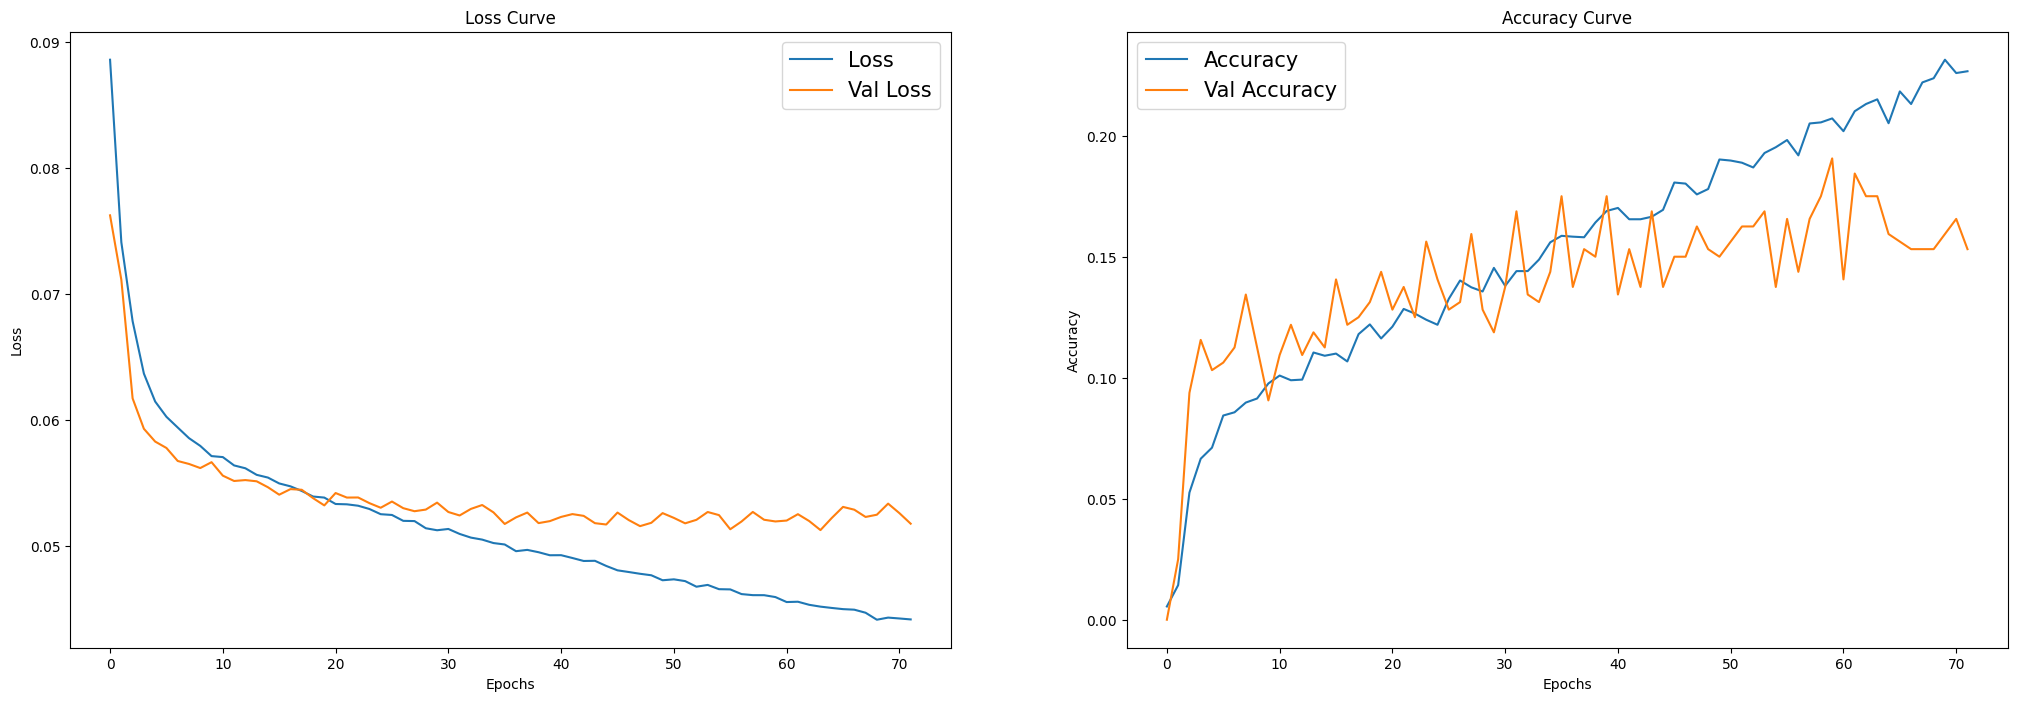

In [869]:
plot_graph(stepwise_logger)

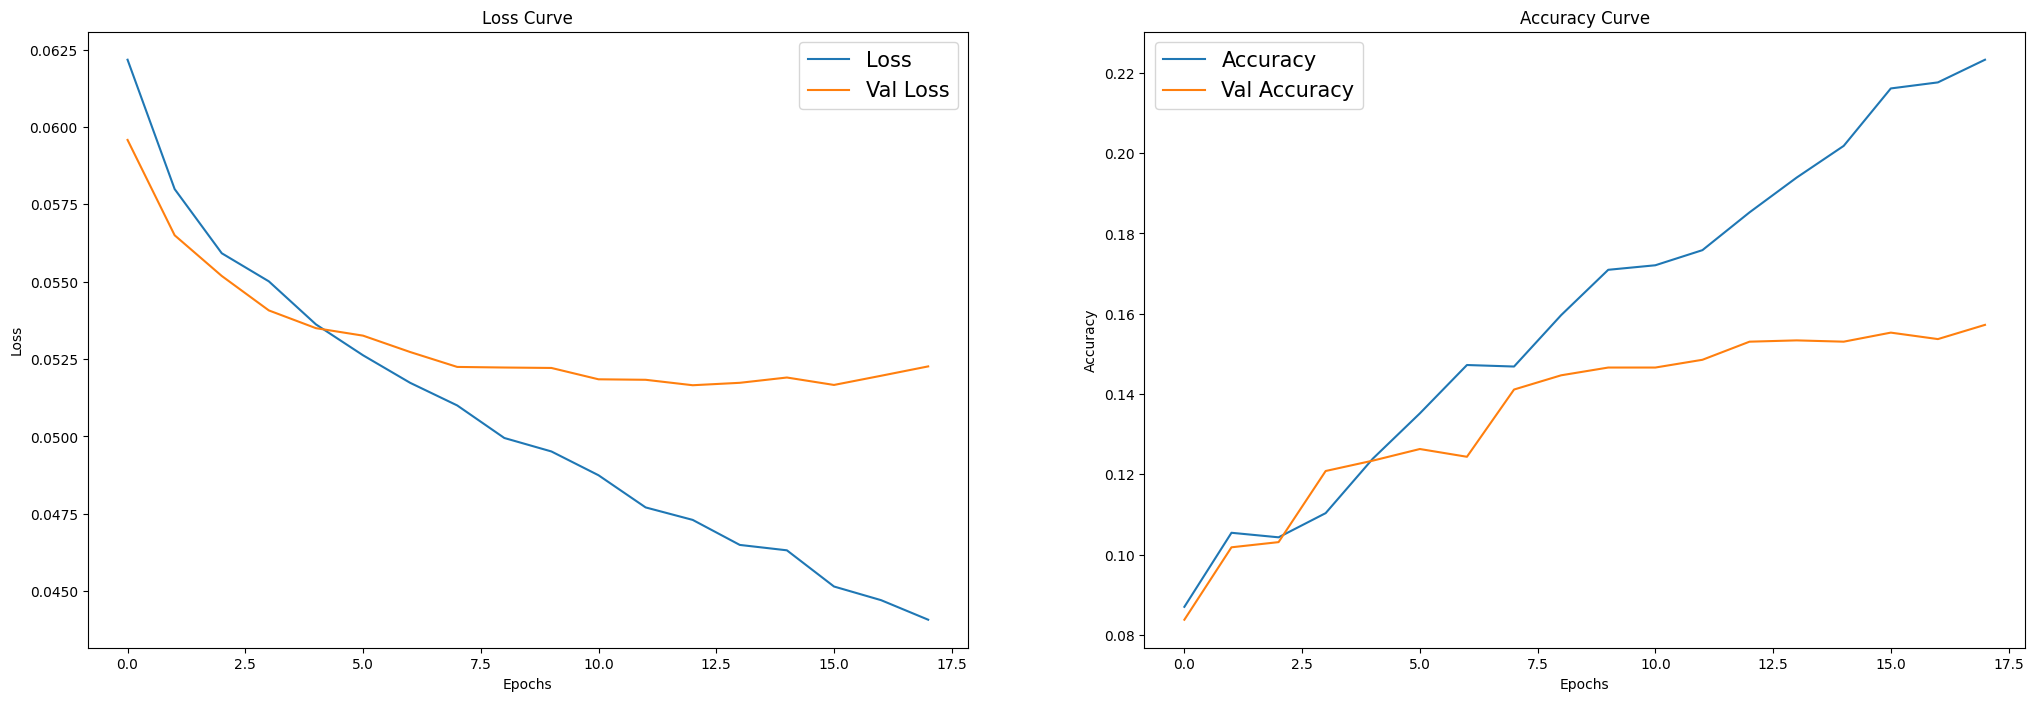

In [870]:
plot_graph(history)

In [871]:
model.evaluate(test_data_generator)

108/108 [==============================] - 1s 6ms/step - loss: 0.0522 - accuracy: 0.1678


[0.05216575041413307, 0.16782407462596893]

In [651]:
move_predictions_2 = model.predict(test_data_generator)

108/108 [==============================] - 1s 5ms/step


In [671]:
initial_pos_preds = [move[:64] for move in move_predictions_2]
final_pos_preds = [move[64:128] for move in move_predictions_2]

initial_pos_preds = np.argmax(initial_pos_preds,axis=1)
final_pos_preds = np.argmax(final_pos_preds,axis=1)

initial_pos_preds = decode_pos(initial_pos_preds)
final_pos_preds = decode_pos(final_pos_preds)

In [672]:
correct_moves, correct_blunders, correct_checks = get_move_acc(initial_pos_preds, final_pos_preds, test_df)

In [673]:
print(str(round(correct_moves/3447*100, 3)) + '%')
print(str(round(correct_blunders/test_df['is_blunder_cp'].sum()*100, 3)) + '%')
print(str(round(correct_checks/test_df['is_check'].sum()*100, 3)) + '%')

16.884%
1.726%
4.613%


In [676]:
valid_init_pos, valid_final_pos, valid_moves, = calculate_valid_moves(initial_pos_preds, final_pos_preds, test_df)

0

In [675]:
print(f"Legal Initial Positions: {valid_init_pos}, {round(valid_init_pos/len(initial_pos_preds)*100,3)}%\nLegal Final Positions: {valid_final_pos}, {round(valid_final_pos/len(initial_pos_preds)*100, 3)}%\nLegal Moves: {valid_moves}, {round(valid_moves/len(initial_pos_preds)*100, 3)}%")

Legal Initial Positions: 3345, 96.788%
Legal Final Positions: 2976, 86.111%
Legal Moves: 1930, 55.845%


# Move prediction model 3
Like the first one, but changing softmax by sigmoid outputs

In [701]:
def create_model_3(board_shape):
    board_input = Input(shape=board_shape)

    cnn1 = Conv2D(8, (3, 3), padding='same', activation='sigmoid')(board_input)
    cnn1 = BatchNormalization()(cnn1)
    cnn1 = Dropout(0.2)(cnn1)
    
    cnn2 = Conv2D(32, (3, 3), padding='same', activation='sigmoid')(cnn1)
    cnn2 = BatchNormalization()(cnn2)
    cnn2 = Dropout(0.2)(cnn2)
    
    cnn3 = Conv2D(64, (3, 3), padding='same', activation='sigmoid')(cnn2)
    cnn3 = BatchNormalization()(cnn3)
    cnn3 = Dropout(0.2)(cnn3)

    latent_space = Flatten()(cnn3)
    
    mlp_initial_pos = Dense(256, activation='sigmoid')(latent_space)
    mlp_initial_pos = Dropout(0.2)(mlp_initial_pos)
    mlp_initial_pos = Dense(128, activation='sigmoid')(mlp_initial_pos)
    mlp_initial_pos = Dropout(0.2)(mlp_initial_pos)

    initial_pos_preds = Dense(64, activation='sigmoid', name = 'initial_pos')(mlp_initial_pos)
    
    combined_features = Concatenate()([latent_space, initial_pos_preds])

    mlp_final_pos = Dense(256, activation='sigmoid')(combined_features)
    mlp_final_pos = Dropout(0.2)(mlp_final_pos)
    mlp_final_pos = Dense(128, activation='sigmoid')(mlp_final_pos)
    mlp_final_pos = Dropout(0.2)(mlp_final_pos)

    final_pos_preds = Dense(64, activation='sigmoid', name = 'final_pos')(mlp_final_pos)

    move_preds = Concatenate()([initial_pos_preds, final_pos_preds])

    model = Model(inputs=board_input, outputs=move_preds)
    return model

In [702]:
INPUT_SHAPE = (8, 8, 6)
model = create_model_3(INPUT_SHAPE)

In [715]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=accuracy)
steps_per_epoch_val = len(val_data_generator)
stepwise_logger = StepwiseLogger(val_data_generator, steps_per_epoch_val, 200)

In [716]:
history = model.fit(train_data_generator, epochs=20, validation_data=val_data_generator, shuffle=False, callbacks=[stepwise_logger, EarlyStopping(patience=5, restore_best_weights=True)])

Epoch 1/20
 36/873 [>.............................] - ETA: 8s - loss: 0.0474 - accuracy: 0.1866

KeyboardInterrupt: 

In [706]:
model.evaluate(test_data_generator)

108/108 [==============================] - 1s 10ms/step - loss: 0.0524 - accuracy: 0.1664


[0.05237376689910889, 0.16637732088565826]

In [707]:
move_predictions_3 = model.predict(test_data_generator)

108/108 [==============================] - 1s 6ms/step


In [711]:
initial_pos_preds = [move[:64] for move in move_predictions_3]
final_pos_preds = [move[64:128] for move in move_predictions_3]

initial_pos_preds = np.argmax(initial_pos_preds,axis=1)
final_pos_preds = np.argmax(final_pos_preds,axis=1)

initial_pos_preds = decode_pos(initial_pos_preds)
final_pos_preds = decode_pos(final_pos_preds)

In [712]:
correct_moves, correct_blunders, correct_checks = get_move_acc(initial_pos_preds, final_pos_preds, test_df)
print(str(round(correct_moves/3447*100, 3)) + '%')
print(str(round(correct_blunders/test_df['is_blunder_cp'].sum()*100, 3)) + '%')
print(str(round(correct_checks/test_df['is_check'].sum()*100, 3)) + '%')

16.681%
1.726%
3.789%


In [713]:
valid_init_pos, valid_final_pos, valid_moves, = calculate_valid_moves(initial_pos_preds, final_pos_preds, test_df)

0

In [714]:
print(f"Legal Initial Positions: {valid_init_pos}, {round(valid_init_pos/len(initial_pos_preds)*100,3)}%\nLegal Final Positions: {valid_final_pos}, {round(valid_final_pos/len(initial_pos_preds)*100, 3)}%\nLegal Moves: {valid_moves}, {round(valid_moves/len(initial_pos_preds)*100, 3)}%")

Legal Initial Positions: 3353, 97.02%
Legal Final Positions: 3005, 86.95%
Legal Moves: 1968, 56.944%


# Move prediction model 4
Adivinar 4096 clases directamente (una clase por casilla). Esto permite obligar a jugar la mejor jugada legal

In [873]:
read_size = 2048
batch_size = 32
num_classes = 64
train_data_generator = DataGenerator(ML_DATA_TRAIN_PATH, read_size, batch_size, num_classes, 27913, single_move=True)
val_data_generator = DataGenerator(ML_DATA_VAL_PATH, read_size, batch_size, num_classes, 3102, single_move=True)
test_data_generator = DataGenerator(ML_DATA_TEST_PATH, read_size, batch_size, num_classes, 3447, single_move=True)

In [899]:
def create_model_4(board_shape):
    board_input = Input(shape=board_shape)

    cnn1 = Conv2D(8, (3, 3), padding='same', activation='sigmoid')(board_input)
    cnn1 = BatchNormalization()(cnn1)
    cnn1 = Dropout(0.2)(cnn1)
    
    cnn2 = Conv2D(32, (3, 3), padding='same', activation='sigmoid')(cnn1)
    cnn2 = BatchNormalization()(cnn2)
    cnn2 = Dropout(0.2)(cnn2)
    
    cnn3 = Conv2D(64, (3, 3), padding='same', activation='sigmoid')(cnn2)
    cnn3 = BatchNormalization()(cnn3)
    cnn3 = Dropout(0.2)(cnn3)

    latent_space = Flatten()(cnn3)
    
    mlp_initial_pos = Dense(256, activation='sigmoid')(latent_space)
    mlp_initial_pos = Dropout(0.2)(mlp_initial_pos)
    mlp_initial_pos = Dense(128, activation='sigmoid')(mlp_initial_pos)
    mlp_initial_pos = Dropout(0.2)(mlp_initial_pos)

    initial_pos_preds = Dense(64, activation='sigmoid', name = 'initial_pos')(mlp_initial_pos)

    mlp_final_pos = Dense(256, activation='sigmoid')(latent_space)
    mlp_final_pos = Dropout(0.2)(mlp_final_pos)
    mlp_final_pos = Dense(128, activation='sigmoid')(mlp_final_pos)
    mlp_final_pos = Dropout(0.2)(mlp_final_pos)

    final_pos_preds = Dense(64, activation='sigmoid', name = 'final_pos')(mlp_final_pos)

    move_input = Concatenate()([latent_space, initial_pos_preds, final_pos_preds])

    mlp_move = Dense(256, activation='sigmoid')(move_input)
    mlp_final_pos = Dropout(0.2)(mlp_final_pos)
    mlp_move = Dense(4096, activation='softmax')(mlp_move)

    model = Model(inputs=board_input, outputs=mlp_move)
    return model

In [900]:
INPUT_SHAPE = (8, 8, 6)
model = create_model_4(INPUT_SHAPE)
model.summary()

Model: "model_45"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_46 (InputLayer)          [(None, 8, 8, 6)]    0           []                               
                                                                                                  
 conv2d_135 (Conv2D)            (None, 8, 8, 8)      440         ['input_46[0][0]']               
                                                                                                  
 batch_normalization_135 (Batch  (None, 8, 8, 8)     32          ['conv2d_135[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 dropout_342 (Dropout)          (None, 8, 8, 8)      0           ['batch_normalization_135[

In [901]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics='accuracy')
steps_per_epoch_val = len(val_data_generator)
stepwise_logger = StepwiseLogger(val_data_generator, steps_per_epoch_val, 200)

In [902]:
history = model.fit(train_data_generator, epochs=20, validation_data=val_data_generator, shuffle=False, callbacks=[stepwise_logger, EarlyStopping(patience=5, restore_best_weights=True)])

Epoch 1/20
873/873 [==============================] - 13s 13ms/step - loss: 5.3224 - accuracy: 0.1130 - val_loss: 5.2908 - val_accuracy: 0.1160
Epoch 2/20
873/873 [==============================] - 9s 11ms/step - loss: 4.8680 - accuracy: 0.1547 - val_loss: 5.0821 - val_accuracy: 0.1414
Epoch 3/20
873/873 [==============================] - 9s 11ms/step - loss: 4.5215 - accuracy: 0.1630 - val_loss: 4.9539 - val_accuracy: 0.1450
Epoch 4/20
873/873 [==============================] - 10s 11ms/step - loss: 4.2214 - accuracy: 0.1867 - val_loss: 4.8673 - val_accuracy: 0.1579
Epoch 5/20
873/873 [==============================] - 9s 10ms/step - loss: 3.9880 - accuracy: 0.1988 - val_loss: 4.8272 - val_accuracy: 0.1595
Epoch 6/20
873/873 [==============================] - 9s 10ms/step - loss: 3.7490 - accuracy: 0.2150 - val_loss: 4.8917 - val_accuracy: 0.1643
Epoch 7/20
873/873 [==============================] - 9s 10ms/step - loss: 3.5170 - accuracy: 0.2372 - val_loss: 4.9599 - val_accuracy: 0.16

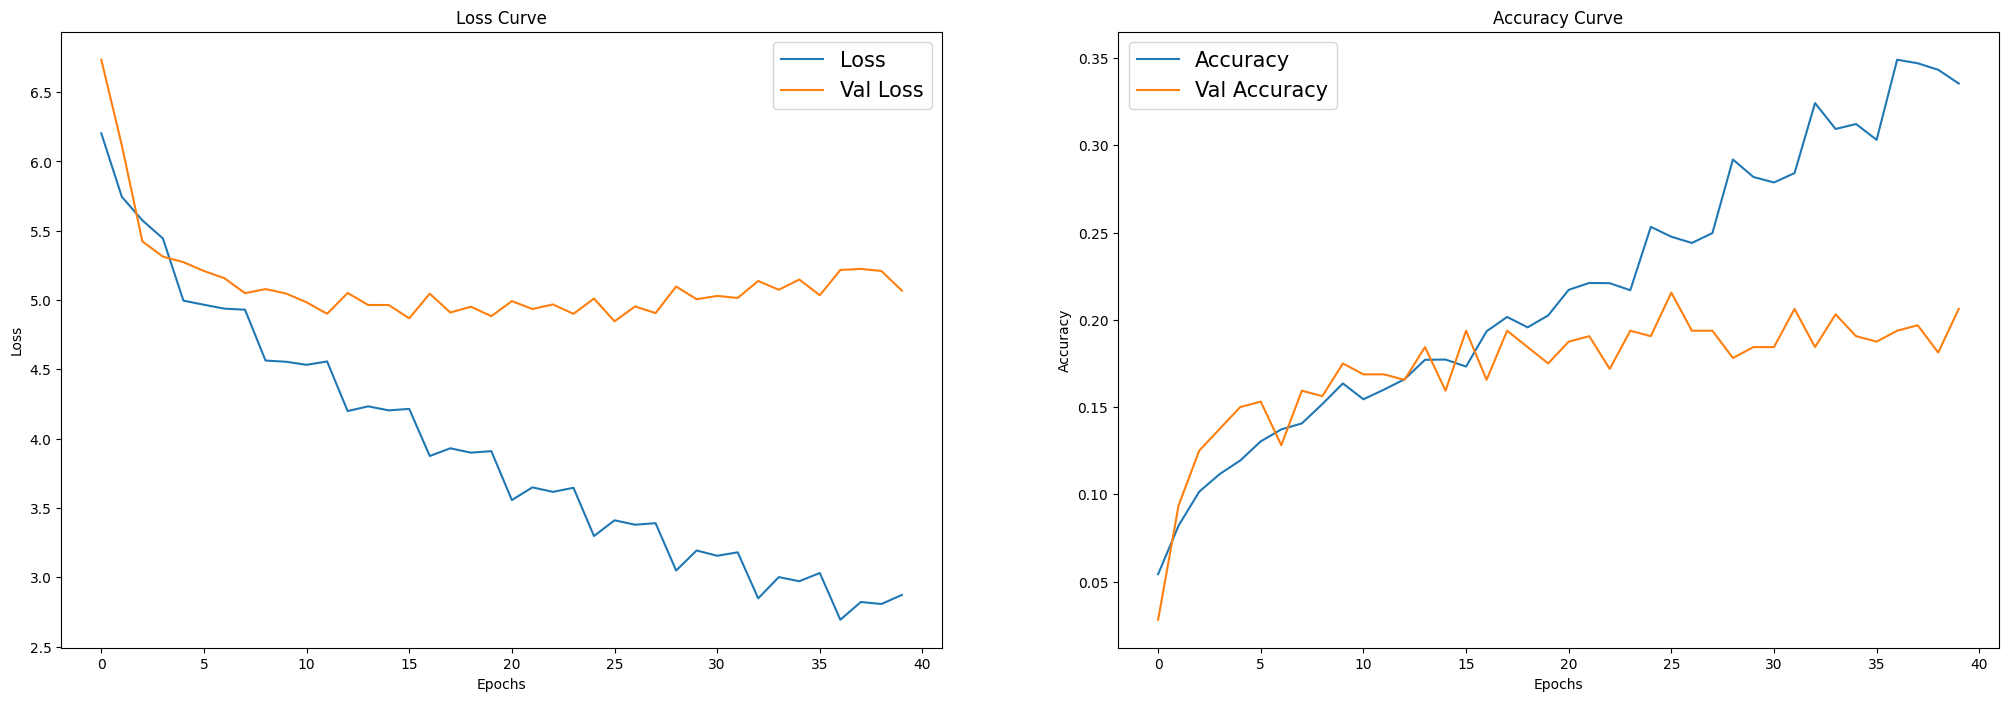

In [903]:
plot_graph(stepwise_logger)

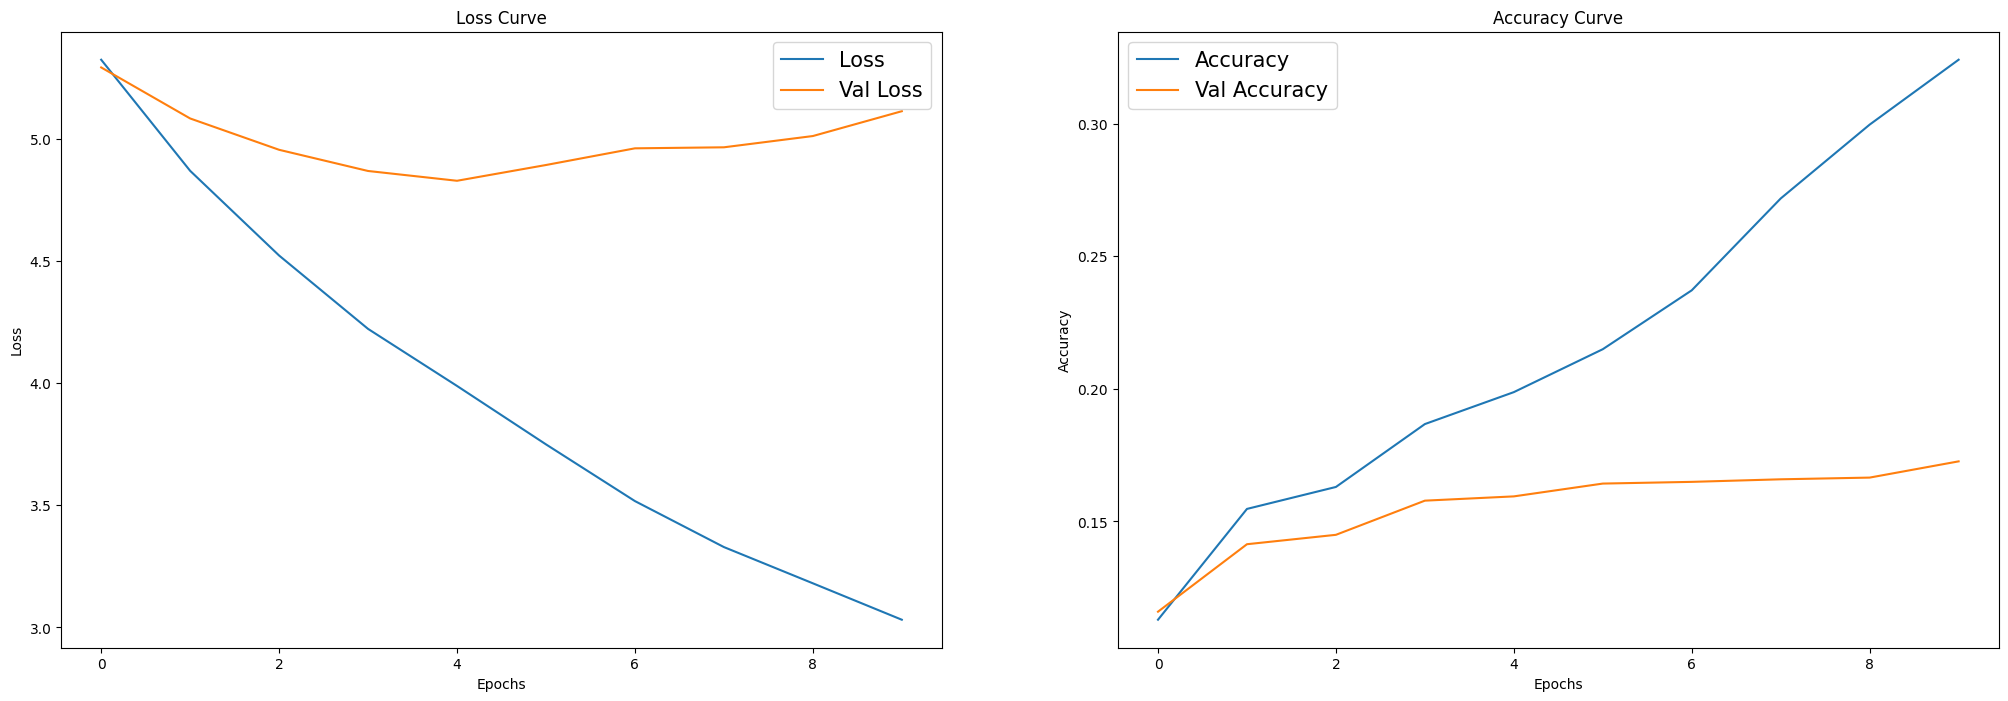

In [904]:
plot_graph(history)

In [905]:
model.evaluate(test_data_generator)

108/108 [==============================] - 1s 6ms/step - loss: 4.8606 - accuracy: 0.1632


[4.860579490661621, 0.1631944477558136]

In [886]:
move_predictions_4 = model.predict(test_data_generator)

108/108 [==============================] - 1s 6ms/step


In [887]:
moves_preds = np.argmax(move_predictions_4,axis=1)

In [888]:
moves_preds_one_hot = [np.zeros(4096, dtype=int) for _ in moves_preds]
for idx, array in zip(moves_preds, moves_preds_one_hot):
    array[idx] = 1

In [889]:
def get_single_move_acc(move_preds, generator):
    correct_moves = 0
    correct_blunders = 0
    correct_checks = 0
    i = 0
    for batch in generator:
        for entry in batch[1]:
            if (move_preds[i] == entry).sum() == 4096:
                correct_moves += 1
            i += 1
            
    return correct_moves, correct_blunders, correct_checks

In [892]:
correct_moves, correct_blunders, correct_checks = get_single_move_acc(moves_preds_one_hot, test_data_generator)
print(str(round(correct_moves/3456*100, 3)) + '%')
print(str(round(correct_blunders/test_df['is_blunder_cp'].sum()*100, 3)) + '%')
print(str(round(correct_checks/test_df['is_check'].sum()*100, 3)) + '%')

17.101%
0.0%
0.0%


In [891]:
valid_init_pos, valid_final_pos, valid_moves, = calculate_valid_moves(initial_pos_preds, final_pos_preds, test_df)

0

In [ ]:
print(f"Legal Initial Positions: {valid_init_pos}, {round(valid_init_pos/len(initial_pos_preds)*100,3)}%\nLegal Final Positions: {valid_final_pos}, {round(valid_final_pos/len(initial_pos_preds)*100, 3)}%\nLegal Moves: {valid_moves}, {round(valid_moves/len(initial_pos_preds)*100, 3)}%")